# Datathon — Jour 1 : Comprendre le corpus (affaire Ultia × CNC)

**Objectif du jour :** lire, comprendre et analyser le corpus. Remplir la grille à 5 axes (Acteurs / Narratifs / Propagation / Coordination / Sémantique), produire une timeline et 2-3 chiffres clés.

**Règle d'or (slide 'le piège à éviter') :** ce n'est PAS un cas de fausse information, c'est un déferlement viral. On décrit la dynamique avant de juger. Ton neutre.

**On ne touche pas encore aux agents.** Aujourd'hui = analyse pure.

---
### Convention d'équipe (à respecter par les 9 pour que les chiffres soient comparables)
- Colonne temps de référence : `Date` (datetime).
- Fenêtre de crise principale : **26-30 mars 2026**.
- Un *message original* = ligne où `Engagement Type` est vide.
- Toujours travailler sur `message_normalizer` pour le texte (déjà nettoyé).

## 0. Setup & chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- Sur Colab : décommenter pour uploader data.xlsx ---
from google.colab import files
files.upload()

df = pd.read_excel('data.xlsx')
df['Date'] = pd.to_datetime(df['Date'])
print('Lignes:', len(df), '| Colonnes:', df.shape[1])
print('Période:', df['Date'].min(), '->', df['Date'].max())
df.head(3)

Saving data.xlsx to data.xlsx
Lignes: 35396 | Colonnes: 30
Période: 2026-03-19 23:13:01 -> 2026-05-01 21:43:00


,Date,Url,Domain,Sentiment,Language,Country,City Code,Author,City,Expanded URLs,...,X Reply to,X Repost of,X Posts,X Verified,Reach,Engagement Type,Hashtags,postID,postDate,message_normalizer
0,2026-05-01 21:43:00,http://twitter.com/Chaumont_Loire/statuses/205...,twitter.com,neutral,fr,France,NaN,Chaumont_Loire,NaN,https://www.cnc.fr/cinema/actualites/le-jardin...,...,NaN,NaN,9211,False,3434,NaN,#googlealerts,1,2026-05-01,« le jardin fait son cinema » au festival int...
1,2026-05-01 21:38:40,http://twitter.com/GuzmanStephane/statuses/205...,twitter.com,neutral,fr,France,NaN,GuzmanStephane,NaN,https://x.com/FrDesouche/status/20501420077717...,...,NaN,http://twitter.com/destinationcine/statuses/20...,348374,False,851,RETWEET,NaN,2,2026-05-01,"rt @ destinationcine le clip "" storm "" de roma..."
2,2026-05-01 21:37:39,http://twitter.com/Lancelo34643571/statuses/20...,twitter.com,neutral,fr,France,NaN,Lancelo34643571,NaN,https://x.com/JPatrierLeitus/status/2049899199...,...,NaN,http://twitter.com/FrDesouche/statuses/2050109...,126326,False,2039,RETWEET,NaN,3,2026-05-01,rt @ frdesouche la choregraphie est formidable...


## 1. Vue d'ensemble — les 4 chiffres qui cadrent tout

Avant les 5 axes, on pose le décor. Ces chiffres sont le socle des slides.

In [2]:
print('Messages totaux      :', len(df))
print('Comptes uniques      :', df['Author'].nunique())
print('Langue               :', df['Language'].unique(), '(100% FR)')
print('Part de RETWEET       : {:.1f}%'.format((df['Engagement Type']=='RETWEET').mean()*100))
print('Messages originaux    :', df['Engagement Type'].isna().sum())
print()
print(df['Engagement Type'].value_counts(dropna=False))
print()
print('==> LECTURE : 85.8% de retweets, seulement 671 messages originaux.')
print("    La crise est une CAISSE DE RÉSONANCE, pas une production massive de contenu.")
print('    Quasiment tout le volume = de l amplification.')

Messages totaux      : 35396
Comptes uniques      : 10437
Langue               : ['fr'] (100% FR)
Part de RETWEET       : 85.8%
Messages originaux    : 671

Engagement Type
RETWEET    30368
REPLY       3623
QUOTE        734
NaN          671
Name: count, dtype: int64

==> LECTURE : 85.8% de retweets, seulement 671 messages originaux.
    La crise est une CAISSE DE RÉSONANCE, pas une production massive de contenu.
    Quasiment tout le volume = de l amplification.


## 2. AXE PROPAGATION — Timeline, pics, vitesse
*Comment ça circule ? Patient zéro, pics de volume, vitesse, amplitude.*

TOP 5 jours en volume:
Date
2026-03-27    7303
2026-03-26    6775
2026-03-29    4932
2026-03-28    3988
2026-03-30    2012
dtype: int64

Heure de pic max: 2026-03-26 16:00:00 -> 751 messages/h


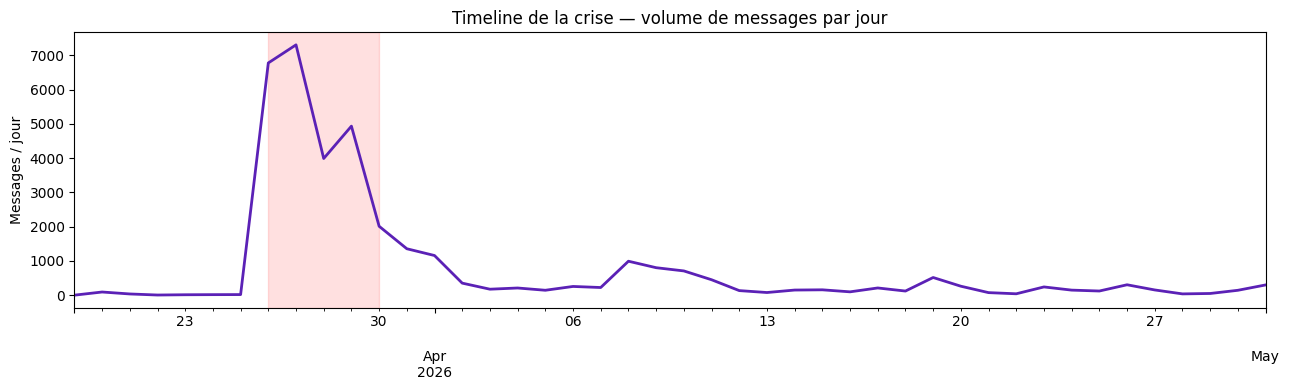

In [3]:
daily = df.set_index('Date').resample('D').size()
hourly = df.set_index('Date').resample('h').size()

print('TOP 5 jours en volume:')
print(daily.sort_values(ascending=False).head(5))
print()
print('Heure de pic max:', hourly.idxmax(), '->', hourly.max(), 'messages/h')

fig, ax = plt.subplots(figsize=(13,4))
daily.plot(ax=ax, color='#5B21B6', lw=2)
ax.set_title('Timeline de la crise — volume de messages par jour')
ax.set_ylabel('Messages / jour'); ax.set_xlabel('')
ax.axvspan('2026-03-26','2026-03-30', alpha=0.12, color='red')
plt.tight_layout(); plt.show()

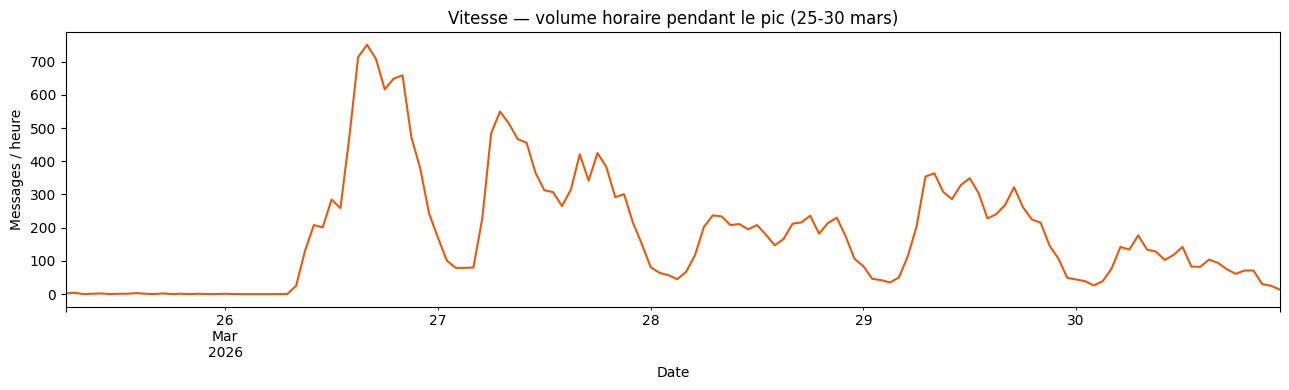

Patient zéro candidat (1er message original) :
   2026-03-20 02:00:41 | samos_84


In [4]:
# Zoom horaire sur la fenêtre de crise — montre la VITESSE
crise = df[(df['Date']>='2026-03-25')&(df['Date']<'2026-03-31')]
ch = crise.set_index('Date').resample('h').size()
fig, ax = plt.subplots(figsize=(13,4))
ch.plot(ax=ax, color='#EA580C')
ax.set_title('Vitesse — volume horaire pendant le pic (25-30 mars)')
ax.set_ylabel('Messages / heure'); plt.tight_layout(); plt.show()

print('Patient zéro candidat (1er message original) :')
orig = df[df['Engagement Type'].isna()].sort_values('Date')
print('  ', orig['Date'].iloc[0], '|', orig['Author'].iloc[0])

**Lecture propagation :** la crise explose le **26-27 mars** (pic à 7 300 msg/jour, 751 msg/h le 26 à 16h), reste forte 4 jours, puis retombe brutalement le 31. Profil classique de *flambée virale* : montée fulgurante, plateau court, extinction rapide.

## 3. AXE ACTEURS — Qui parle ? Qui amplifie ?
*Médias, militants, influenceurs, anonymes, comptes suspects.*

Distinction clé : **qui POSTE beaucoup** (volume) ≠ **qui est AMPLIFIÉ** (influence réelle).

In [5]:
print('--- Comptes qui POSTENT le plus (volume brut) ---')
print(df['Author'].value_counts().head(10))
print()
print('--- Comptes les plus AMPLIFIÉS (= sources des retweets) ---')
rt = df[df['Engagement Type']=='RETWEET']
top_amp = rt['X Repost of'].value_counts().head(10)
print(top_amp)
print()
print('==> Les vrais moteurs de la crise sont les comptes AMPLIFIÉS,')
print('    pas les comptes qui spamment. On y voit des élus (Bellamy,')
print('    Maréchal), des comptes militants, et le CNC lui-même.')

--- Comptes qui POSTENT le plus (volume brut) ---
Author
LaPravda99         111
alain_co           108
Alain_83740        105
RabbinAvZemmour    101
nraednioa           97
3_V75               89
Zeauran             88
SYKANHO             87
ppcs27              85
smav31              74
Name: count, dtype: int64

--- Comptes les plus AMPLIFIÉS (= sources des retweets) ---
X Repost of
http://twitter.com/LeDindonFiscal/statuses/2038199978619703349    654
http://twitter.com/Crohnfighter/statuses/2045798671430582710      623
http://twitter.com/charlesvillaa/statuses/2037979931444158475     596
http://twitter.com/jon_delorraine/statuses/2037550734615409015    572
http://twitter.com/fxbellamy/statuses/2037939134992441518         570
http://twitter.com/LeCNC/statuses/2037169894253302130             509
http://twitter.com/MarionMarechal/statuses/2037597335652348246    493
http://twitter.com/anatolium/statuses/2037589531411509333         488
http://twitter.com/GuilhemCarayon/statuses/20371451020

## 4. AXE NARRATIFS — Quels discours ?
*« Copinage » vs « censure » vs « défense d'Ultia ». Mots-clés, thématiques.*

In [6]:
# Hashtags
c = Counter()
for row in df['Hashtags'].dropna():
    for tag in str(row).replace(';',',').split(','):
        tag = tag.strip().lower()
        if tag: c[tag]+=1
print('TOP 15 hashtags:')
for t,n in c.most_common(15): print(f'  {n:>4}  {t}')

# /!\ PIÈGE détecté : #racketfiscal / #carburant / #vachealait arrivent en tête
# -> ce sont des retweets PARASITES (pub/arnaque) qui polluent le corpus.
# Le hashtag réellement lié au sujet est #cnc (446) et #ultia (177).

TOP 15 hashtags:
   655  #racketfiscal
   655  #carburant
   655  #vachealait
   446  #cnc
   177  #ultia
    51  #twitch
    46  #cinéma
    46  #europe1
    46  #europe1matin
    46  #scandale
    41  #francetv
    39  #breakingnews
    39  #ue
    33  #subventions
    32  #qag


In [7]:
# Mots les plus fréquents dans les messages normalisés (hors stopwords basiques)
stop = set('rt le la les de des du un une et a à en au aux pour que qui ce se sur'
           ' pas plus son sa ses est il elle on vous nous je tu ne dans par avec'
           ' mais ou où donc or ni car the of to vous etre être fait font'.split())
words = Counter()
for t in df['message_normalizer'].dropna():
    for w in str(t).split():
        w = w.strip('.,!?()[]"\':;@#')
        if len(w)>3 and w not in stop: words[w]+=1
print('TOP 25 mots du corpus:')
for w,n in words.most_common(25): print(f'  {n:>5}  {w}')

TOP 25 mots du corpus:
  21900  https
  12815  argent
  11396  euros
   9494  gauche
   9213  francais
   9168  cette
   8238  ultia
   8141  talent
   7416  tout
   7210  public
   7001  sans
   6877  france
   6805  extreme
   6322  commission
   6215  fonds
   6143  meme
   5988  votre
   5969  millions
   5708  bien
   5646  droite
   5558  tous
   5428  comme
   5385  subventions
   5368  finance
   5046  entre


## 5. AXE COORDINATION — Est-ce orchestré ?
*Synchronies, copier-coller, comptes récents, clusters.*

Signal le plus parlant : **les messages identiques copiés en masse**.

In [8]:
mn = df['message_normalizer'].dropna()
vc = mn.value_counts()
dup = vc[vc>1]
print(f'Textes dupliqués (postés >1 fois) : {dup.sum()} messages sur {len(mn)} '
      f'({dup.sum()/len(mn)*100:.0f}% du corpus)')
print()
print('TOP 5 textes les plus copiés:')
for t,n in vc.head(5).items():
    print(f'  x{n}  {str(t)[:80]}')
print()
print('==> ATTENTION nuance : un fort taux de copier-coller en analyse Twitter')
print('    = surtout des RETWEETS (reprise mécanique), PAS forcément une')
print('    coordination malveillante. Il faut séparer retweet vs quote/reply')
print('    identiques pour vraiment parler de coordination.')

Textes dupliqués (postés >1 fois) : 29959 messages sur 35396 (85% du corpus)

TOP 5 textes les plus copiés:
  x654  rt @ ledindonfiscal 111 , 50  pour 52 litres de diesel . À 2 , 12  le litre , je
  x623  rt @ crohnfighter vous vous souvenez des 2 idiotes rances camille et justine , q
  x596  rt @ charlesvillaa vous etes un elu de la republique et vous diffusez une fausse
  x572  rt @ jon _ delorraine ce que les francais demandent : que charles alloncle se pe
  x570  rt @ fxbellamy nommee par le cnc dans la commission qui distribue les fonds du p

==> ATTENTION nuance : un fort taux de copier-coller en analyse Twitter
    = surtout des RETWEETS (reprise mécanique), PAS forcément une
    coordination malveillante. Il faut séparer retweet vs quote/reply
    identiques pour vraiment parler de coordination.


In [9]:
# Coordination plus fine : textes ORIGINAUX/quotes identiques (hors retweet)
non_rt = df[df['Engagement Type']!='RETWEET']
vc2 = non_rt['message_normalizer'].dropna().value_counts()
print('Textes non-retweet copiés >1 fois (signal de coordination réel):')
for t,n in vc2[vc2>1].head(10).items():
    print(f'  x{n}  {str(t)[:80]}')

Textes non-retweet copiés >1 fois (signal de coordination réel):
  x9  quand on analyse les beneficiaires du fond , on comprend qu il ne s agit pas d u
  x3  voici ce que j ai transmis au cnc : fyi . transmis cnc , ministere , gpe canal ,
  x3  voila ce que j ai transmis au cnc avec un espoir de retour , disons , faible . f
  x3  Ça fait des annees que tout le monde dit qu il se servent mechamment du cnc , ma
  x3  voila ce que j ai transmis au cnc avec un espoir de retour , disons , faible . o
  x2   # seriesmania2026 : le forum ouvre les portes de sa music roomafin de mettre en
  x2   @ lecnc @ gaetanbruel @ ministerecc @ challoncle est ce normal que l impot des 
  x2   @ sebmusset ils vont reussir a faire passer la pilule en faisant sauter le fusi
  x2   « nuestra tierra » : le premier # documentaire de lucrecia martelhttps : / / t 
  x2  j attends toujours une reponse . je vais attendre longtemps ! fyi . transmis cnc


## 6. AXE SÉMANTIQUE — Sur quel ton ?
*Sentiment, montée en agressivité, glissements de vocabulaire.*

Sentiment global:
Sentiment
neutral     23476
negative    10861
positive     1059
Name: count, dtype: int64
  -> 66% neutre, 31% négatif, 3% positif



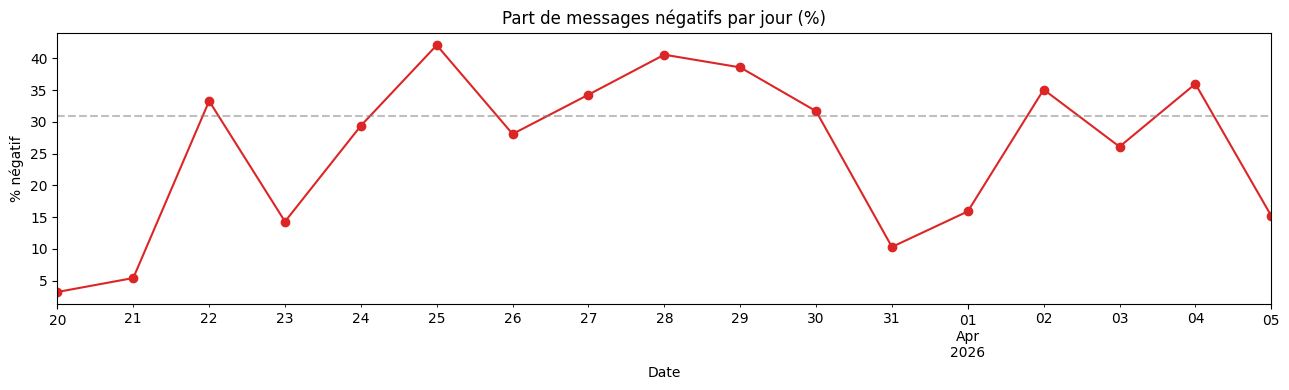

Pic de négativité: 25 mars (42%) et 28 mars (41%) — la tension monte AVANT
le pic de volume, puis culmine pendant.


In [10]:
print('Sentiment global:')
print(df['Sentiment'].value_counts())
print('  -> 66% neutre, 31% négatif, 3% positif')
print()
# Sentiment dans le temps
d = df.set_index('Date')
neg = d[d['Sentiment']=='negative'].resample('D').size()
tot = d.resample('D').size()
ratio = (neg/tot*100).round(1)

fig, ax = plt.subplots(figsize=(13,4))
ratio.loc['2026-03-20':'2026-04-05'].plot(ax=ax, marker='o', color='#DC2626')
ax.set_title('Part de messages négatifs par jour (%)')
ax.set_ylabel('% négatif'); ax.axhline(31, ls='--', color='grey', alpha=.5)
plt.tight_layout(); plt.show()
print('Pic de négativité: 25 mars (42%) et 28 mars (41%) — la tension monte AVANT')
print('le pic de volume, puis culmine pendant.')

## 7. Synthèse — la grille 5 axes remplie (brouillon pour les slides)

| Axe | Chiffre clé | Lecture |
|---|---|---|
| **Propagation** | Pic 26-27 mars, 7300 msg/j, 751 msg/h | Flambée virale : montée fulgurante, plateau 4j, extinction le 31 |
| **Acteurs** | 10 437 comptes, 9% certifiés | Moteurs = comptes amplifiés (élus, militants), pas les spammeurs |
| **Narratifs** | #cnc (446), #ultia (177) | + hashtags parasites (#racketfiscal) à filtrer |
| **Coordination** | 85% de textes dupliqués | MAIS = retweets surtout ; coordination réelle à isoler hors-RT |
| **Sémantique** | 31% négatif, pics à 42% | Tension monte avant le volume, culmine pendant |

### 3 chiffres clés à mettre en avant
1. **85,8% de retweets** → une crise d'amplification, pas de création.
2. **Pic à 751 messages/heure** le 26 mars 16h → vitesse de déferlement.
3. **Seulement 671 messages originaux** sur 35 396 → tout repose sur une poignée de sources.

### Pistes d'agents (pour Jour 2 — à valider en équipe)
- **Agent Détecteur de pic** : surveille le volume horaire, alerte quand ça s'emballe.
- **Agent Classifieur de narratifs** : range chaque message dans censure / copinage / défense.
- **Agent Nettoyeur de bruit** : isole les retweets parasites (pub/arnaque) du vrai sujet.
- **Agent Cartographe d'acteurs** : distingue amplificateurs réels vs comptes à volume.